# Notebook 8 - Prediction, Explainability & Business Insights

The models can predict churn. Now we answer the lecturer’s favourite questions:

1. **Why** did the model flag this customer?
2. **Which features** matter most?
3. **What should the business do** with these scores?

We explain the model with **permutation importance**,
walk through example predictions, and turn findings into retention actions.

| | |
|---|---|
| **Input** | processed data, GA/PSO winner, baseline + TabNet metrics, TabNet probabilities |
| **Output** | importance charts, retention playbook, final leaderboard |
| **Why it is needed** | Links modelling results to analysis, prediction, and business value. |

## What is permutation importance?

Idea in one sentence:

> Shuffle one feature’s values. If the model gets much worse, that feature was important.

Steps:

1. Measure the model’s F1 on the real test set (**baseline score**)
2. For each feature:
   - randomly shuffle only that column
   - score the model again
   - importance = baseline score − shuffled score
3. Features that cause a big drop are the key churn drivers


In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"
MODEL_FOLDER = "../models"
os.makedirs(FIGURE_FOLDER, exist_ok=True)

X_train = pd.read_csv(CLEAN_FOLDER + "/X_train.csv")
X_test = pd.read_csv(CLEAN_FOLDER + "/X_test.csv")
y_train = pd.read_csv(CLEAN_FOLDER + "/y_train.csv")["Churn"]
y_test = pd.read_csv(CLEAN_FOLDER + "/y_test.csv")["Churn"]
id_test = pd.read_csv(CLEAN_FOLDER + "/id_test.csv")

with open(CLEAN_FOLDER + "/nia_feature_selection_winner.json", "r", encoding="utf-8") as f:
    winner = json.load(f)

win_feats = winner["winning_features"]
print("Winner algorithm:", winner["winner"])
print("Winning features:", len(win_feats))

Winner algorithm: GA
Winning features: 17


## Step 1 - Train a Random Forest on the winning features

We use Random Forest for permutation importance because:

- it is fast
- tree models are easy to re-score after shuffling
- it uses the same winning feature set as TabNet

(TabNet’s own importance from notebook 7 is shown later for comparison.)

In [2]:
Xtr = X_train[win_feats].copy()
Xte = X_test[win_feats].copy()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(Xtr, y_train)
joblib.dump(rf_model, MODEL_FOLDER + "/rf_winning_subset.joblib")

rf_proba = rf_model.predict_proba(Xte)[:, 1]
rf_pred = []
for p in rf_proba:
    if p >= 0.5:
        rf_pred.append(1)
    else:
        rf_pred.append(0)

baseline_f1 = f1_score(y_test, rf_pred)
print("RF on winning subset — test F1:", round(baseline_f1, 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))

RF on winning subset — test F1: 0.7402
Recall: 0.8474
Precision: 0.6571


## Step 2 - Permutation importance (from scratch with a simple loop)

                              feature  f1_after_shuffle  importance
                               Tenure          0.365385    0.374845
                             Complain          0.602353    0.137877
                      NumberOfAddress          0.683371    0.056859
                 MaritalStatus_Single          0.694836    0.045394
                    DaySinceLastOrder          0.704762    0.035468
                      WarehouseToHome          0.705882    0.034348
                             CityTier          0.708804    0.031426
                    SatisfactionScore          0.709977    0.030253
        PreferedOrderCat_Mobile Phone          0.718072    0.022158
                      UnhappyComplain          0.724374    0.015856
        PreferredLoginDevice_Computer          0.724374    0.015856
                           CouponUsed          0.728507    0.011723
  PreferedOrderCat_Laptop & Accessory          0.733179    0.007051
                            IsDormant          0

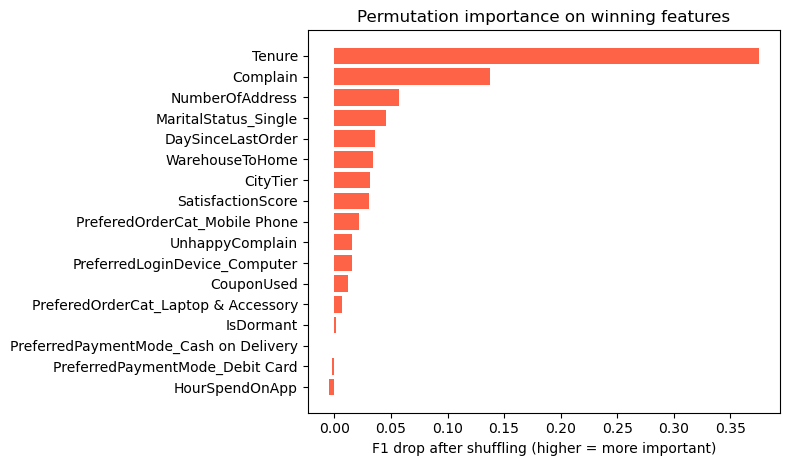

In [3]:
importance_rows = []

for feature_name in win_feats:
    X_shuffled = Xte.copy()

    # Shuffle only this one column
    shuffled_values = X_shuffled[feature_name].tolist()
    random.shuffle(shuffled_values)
    X_shuffled[feature_name] = shuffled_values

    shuffled_proba = rf_model.predict_proba(X_shuffled)[:, 1]
    shuffled_pred = []
    for p in shuffled_proba:
        if p >= 0.5:
            shuffled_pred.append(1)
        else:
            shuffled_pred.append(0)

    shuffled_f1 = f1_score(y_test, shuffled_pred)
    drop = baseline_f1 - shuffled_f1
    importance_rows.append([feature_name, shuffled_f1, drop])

perm_table = pd.DataFrame(
    importance_rows, columns=["feature", "f1_after_shuffle", "importance"]
)
perm_table = perm_table.sort_values("importance", ascending=False)
perm_table.to_csv(CLEAN_FOLDER + "/permutation_importance.csv", index=False)

print(perm_table.to_string(index=False))

plt.figure(figsize=(8, max(3, 0.28 * len(perm_table))))
plt.barh(perm_table["feature"][::-1], perm_table["importance"][::-1], color="tomato")
plt.xlabel("F1 drop after shuffling (higher = more important)")
plt.title("Permutation importance on winning features")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/8_permutation_importance.png", dpi=150)
plt.show()

### How to read this chart

A taller bar means: when we destroy that feature’s information by shuffling,
prediction quality falls more. Those are the drivers to discuss in the viva.

We also compare with TabNet’s built-in importance from notebook 7. The two
methods will not match perfectly (different models), but strong features often
appear near the top in both.

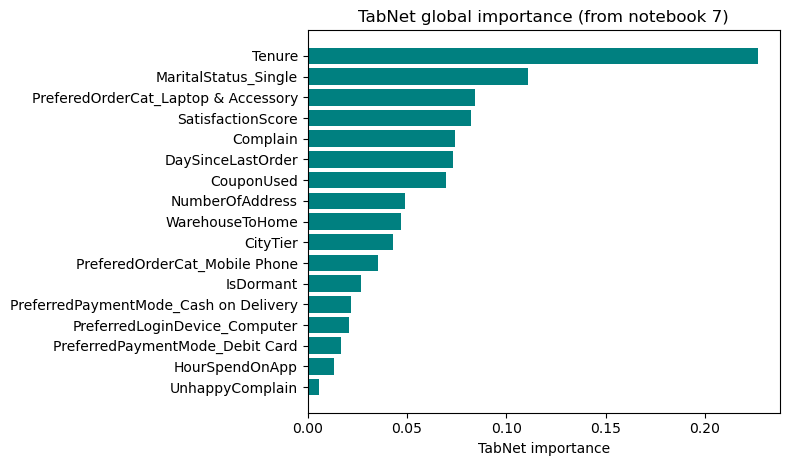

Top 5 by permutation importance:
             feature  importance
              Tenure    0.374845
            Complain    0.137877
     NumberOfAddress    0.056859
MaritalStatus_Single    0.045394
   DaySinceLastOrder    0.035468

Top 5 by TabNet importance:
                            feature  importance
                             Tenure    0.226539
               MaritalStatus_Single    0.110900
PreferedOrderCat_Laptop & Accessory    0.084081
                  SatisfactionScore    0.082104
                           Complain    0.074111


In [4]:
tabnet_imp = pd.read_csv(CLEAN_FOLDER + "/tabnet_feature_importance.csv")
tabnet_imp = tabnet_imp.sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(3, 0.28 * len(tabnet_imp))))
plt.barh(tabnet_imp["feature"][::-1], tabnet_imp["importance"][::-1], color="teal")
plt.xlabel("TabNet importance")
plt.title("TabNet global importance (from notebook 7)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/8_tabnet_importance.png", dpi=150)
plt.show()

print("Top 5 by permutation importance:")
print(perm_table.head(5)[["feature", "importance"]].to_string(index=False))
print()
print("Top 5 by TabNet importance:")
print(tabnet_imp.head(5).to_string(index=False))

## Step 3 - Prediction analysis with TabNet scores

We load TabNet test probabilities and group customers into risk bands:

| Band | Probability | Action idea |
|---|---|---|
| High | ≥ 0.70 | Priority outreach / complaint recovery |
| Medium | 0.40 – 0.70 | Soft offer / check-in |
| Low | < 0.40 | Normal service, avoid wasteful discounts |

Customers per risk band:
RiskBand
Low       915
High      199
Medium     12
Name: count, dtype: int64

RiskBand  n_customers  actual_churn_rate
    High          199              0.910
  Medium           12              0.417
     Low          915              0.004


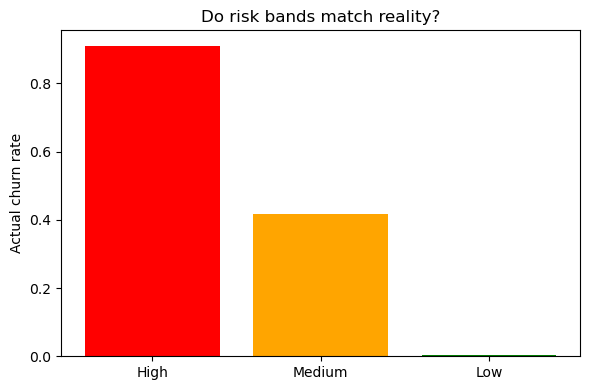

In [5]:
tabnet_proba = np.load(CLEAN_FOLDER + "/tabnet_test_proba_winning.npy")

prediction_rows = []
for i in range(len(tabnet_proba)):
    prob = float(tabnet_proba[i])
    actual = int(y_test.iloc[i])
    customer_id = int(id_test.loc[i, "CustomerID"])

    if prob >= 0.70:
        band = "High"
    elif prob >= 0.40:
        band = "Medium"
    else:
        band = "Low"

    if prob >= 0.5:
        pred = 1
    else:
        pred = 0

    prediction_rows.append([customer_id, actual, pred, round(prob, 4), band])

pred_table = pd.DataFrame(
    prediction_rows,
    columns=["CustomerID", "ActualChurn", "Predicted", "P_churn", "RiskBand"],
)
pred_table.to_csv(CLEAN_FOLDER + "/test_predictions.csv", index=False)

print("Customers per risk band:")
print(pred_table["RiskBand"].value_counts())
print()

# Churn rate inside each band (are high-risk customers really more likely to leave?)
band_summary_rows = []
for band_name in ["High", "Medium", "Low"]:
    band_rows = pred_table[pred_table["RiskBand"] == band_name]
    if len(band_rows) == 0:
        continue
    actual_rate = band_rows["ActualChurn"].mean()
    band_summary_rows.append([band_name, len(band_rows), round(actual_rate, 3)])

band_summary = pd.DataFrame(
    band_summary_rows, columns=["RiskBand", "n_customers", "actual_churn_rate"]
)
print(band_summary.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(band_summary["RiskBand"], band_summary["actual_churn_rate"], color=["red", "orange", "green"])
plt.ylabel("Actual churn rate")
plt.title("Do risk bands match reality?")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/8_risk_bands.png", dpi=150)
plt.show()

## Step 4 - Walk through one high-risk and one low-risk prediction

For the viva, pick one customer and explain:

1. What probability the model gave
2. Whether the customer actually churned
3. Which of their feature values look risky (using the top drivers)

In [6]:
# Find highest and lowest TabNet risk customers
highest_i = 0
lowest_i = 0
for i in range(1, len(tabnet_proba)):
    if tabnet_proba[i] > tabnet_proba[highest_i]:
        highest_i = i
    if tabnet_proba[i] < tabnet_proba[lowest_i]:
        lowest_i = i

top_drivers = perm_table.head(5)["feature"].tolist()

for label, idx in [("HIGH RISK", highest_i), ("LOW RISK", lowest_i)]:
    print("=" * 60)
    print(label)
    print("CustomerID :", int(id_test.loc[idx, "CustomerID"]))
    print("P(churn)   :", round(float(tabnet_proba[idx]), 3))
    print("Actual     :", int(y_test.iloc[idx]), "(1 = left, 0 = stayed)")
    print()
    print("Values on top permutation drivers:")
    for feature_name in top_drivers:
        value = Xte.iloc[idx][feature_name]
        print(" ", feature_name, "=", round(float(value), 4))
    print()

HIGH RISK
CustomerID : 51473
P(churn)   : 1.0
Actual     : 1 (1 = left, 0 = stayed)

Values on top permutation drivers:
  Tenure = 0.0
  Complain = 1.0
  NumberOfAddress = -0.25
  MaritalStatus_Single = 1.0
  DaySinceLastOrder = -0.6

LOW RISK
CustomerID : 52225
P(churn)   : 0.0
Actual     : 0 (1 = left, 0 = stayed)

Values on top permutation drivers:
  Tenure = 1.75
  Complain = 1.0
  NumberOfAddress = -0.5
  MaritalStatus_Single = 0.0
  DaySinceLastOrder = 1.2



## Step 5 - Business retention playbook

We turn model drivers into actions a company can actually run.

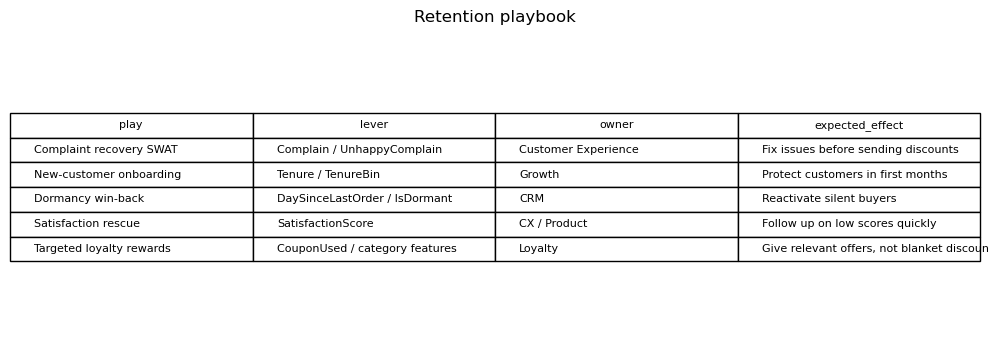

,play,lever,owner,expected_effect
0,Complaint recovery SWAT,Complain / UnhappyComplain,Customer Experience,Fix issues before sending discounts
1,New-customer onboarding,Tenure / TenureBin,Growth,Protect customers in first months
2,Dormancy win-back,DaySinceLastOrder / IsDormant,CRM,Reactivate silent buyers
3,Satisfaction rescue,SatisfactionScore,CX / Product,Follow up on low scores quickly
4,Targeted loyalty rewards,CouponUsed / category features,Loyalty,"Give relevant offers, not blanket discounts"


In [7]:
plays = pd.DataFrame(
    [
        ["Complaint recovery SWAT", "Complain / UnhappyComplain", "Customer Experience", "Fix issues before sending discounts"],
        ["New-customer onboarding", "Tenure / TenureBin", "Growth", "Protect customers in first months"],
        ["Dormancy win-back", "DaySinceLastOrder / IsDormant", "CRM", "Reactivate silent buyers"],
        ["Satisfaction rescue", "SatisfactionScore", "CX / Product", "Follow up on low scores quickly"],
        ["Targeted loyalty rewards", "CouponUsed / category features", "Loyalty", "Give relevant offers, not blanket discounts"],
    ],
    columns=["play", "lever", "owner", "expected_effect"],
)

plays.to_csv(CLEAN_FOLDER + "/retention_plays.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")
table = ax.table(
    cellText=plays.values,
    colLabels=plays.columns,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)
ax.set_title("Retention playbook", pad=16)
fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/8_retention_playbook.png", dpi=150, bbox_inches="tight")
plt.show()

plays

## Step 6 - Final model leaderboard

We gather baseline and TabNet metrics into one comparison chart.

             model       f1   recall   pr_auc
LogisticRegression 0.575000 0.847368 0.672383
      RandomForest 0.723982 0.842105 0.826305
     TabNet_subset 0.924623 0.968421 0.983765
       TabNet_full 0.971576 0.989474 0.998945


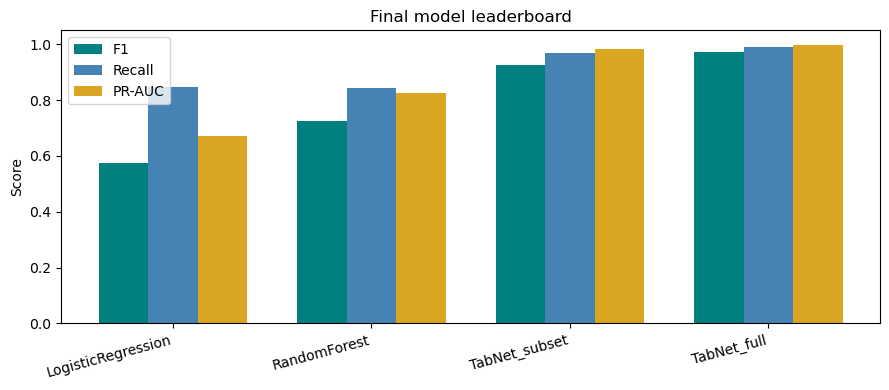

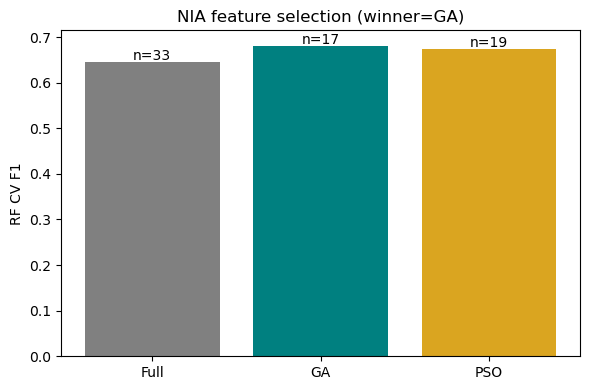

In [8]:
baseline = pd.read_json(CLEAN_FOLDER + "/baseline_metrics.json")
tabnet_metrics = pd.read_json(CLEAN_FOLDER + "/tabnet_metrics.json")

rows = []
for i in range(len(baseline)):
    rows.append(
        [
            baseline.loc[i, "model"],
            baseline.loc[i, "f1"],
            baseline.loc[i, "recall"],
            baseline.loc[i, "pr_auc"],
        ]
    )

for i in range(len(tabnet_metrics)):
    model_name = tabnet_metrics.loc[i, "model"]
    if "winning" in str(model_name).lower():
        label = "TabNet_subset"
    else:
        label = "TabNet_full"
    rows.append(
        [
            label,
            tabnet_metrics.loc[i, "f1"],
            tabnet_metrics.loc[i, "recall"],
            tabnet_metrics.loc[i, "pr_auc"],
        ]
    )

board = pd.DataFrame(rows, columns=["model", "f1", "recall", "pr_auc"])
board.to_csv(CLEAN_FOLDER + "/model_leaderboard.csv", index=False)
print(board.to_string(index=False))

x = list(range(len(board)))
width = 0.25

plt.figure(figsize=(9, 4))
plt.bar([i - width for i in x], board["f1"], width=width, label="F1", color="teal")
plt.bar(x, board["recall"], width=width, label="Recall", color="steelblue")
plt.bar([i + width for i in x], board["pr_auc"], width=width, label="PR-AUC", color="goldenrod")
plt.xticks(x, board["model"], rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Final model leaderboard")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/8_model_leaderboard.png", dpi=150)
plt.show()

# NIA summary chart
ga = json.load(open(CLEAN_FOLDER + "/ga_feature_selection.json", encoding="utf-8"))
pso = json.load(open(CLEAN_FOLDER + "/pso_feature_selection.json", encoding="utf-8"))

plt.figure(figsize=(6, 4))
methods = ["Full", "GA", "PSO"]
f1_vals = [ga["cv_f1_full"], ga["cv_f1_selected"], pso["cv_f1_selected"]]
plt.bar(methods, f1_vals, color=["gray", "teal", "goldenrod"])
plt.ylabel("RF CV F1")
plt.title("NIA feature selection (winner=" + winner["winner"] + ")")
for i in range(len(methods)):
    if methods[i] == "Full":
        n = ga["n_total_features"]
    elif methods[i] == "GA":
        n = ga["n_selected"]
    else:
        n = pso["n_selected"]
    plt.text(i, f1_vals[i] + 0.005, "n=" + str(n), ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/8_nia_summary.png", dpi=150)
plt.show()

## Project wrap-up

### Problem
Predict which e-commerce customers will churn, and explain why.

### Data mining flow
1. Understand data and class imbalance  
2. Explore patterns (complaints, tenure, satisfaction)  
3. Clean, encode, scale, split  
4. Train baselines  
5. Select features with GA and PSO  
6. Train TabNet on the winner  
7. Explain drivers and recommend actions  

### Key findings
- Churn is rare (~17%), so recall / F1 / PR-AUC matter more than accuracy  
- Complaints, short tenure, and low satisfaction are major risk signals  
- GA beat PSO on this run and reduced features while improving RF CV F1  
- TabNet gives strong predictions on the reduced feature set  
- Permutation importance makes those predictions explainable  

### How to use the scores
1. Score customers regularly with the saved TabNet model  
2. Prioritise **High** risk band customers  
3. Route complainers to CX before marketing discounts  
4. Re-run GA/PSO only when the data drifts a lot  
